In [1]:
# https://raw.githubusercontent.com/blastchar/telco-customer-churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv

# Predict whether a customer will churn (leave the company) or not.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)


In [2]:
# =====================================================
# 1. Load Dataset
# =====================================================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [3]:
df['Churn']

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [5]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [6]:
# =====================================================
# 2. Basic Cleaning
# =====================================================

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce" #If conversion fails, don't throw an error. Replace the value with NaN
)

df.dropna(inplace=True)


In [7]:
# =====================================================
# 3. Target Encoding
# =====================================================

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [8]:
# =====================================================
# 4. Features and Target
# =====================================================

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [9]:
# =====================================================
# 5. Numerical & Categorical Columns
# =====================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
# =====================================================
# 6. Preprocessing
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [12]:
# =====================================================
# 7. Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
# =====================================================
# 8. Baseline Pipeline
# =====================================================

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=5000  #At most 5000 optimization steps
            )
        )
    ]
)

baseline_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=5000))])

In [14]:
# =====================================================
# 9. Predictions
# =====================================================

y_pred = baseline_pipeline.predict(
    X_test
)

y_prob = baseline_pipeline.predict_proba(
    X_test
)[:, 1]

In [15]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [16]:
y_prob

array([0.01751303, 0.59192131, 0.00482103, ..., 0.13098875, 0.02525535,
       0.00444712])

In [17]:
# =====================================================
# 10. Accuracy
# =====================================================

baseline_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nBaseline Accuracy:")
print(round(baseline_accuracy, 4))


Baseline Accuracy:
0.8038


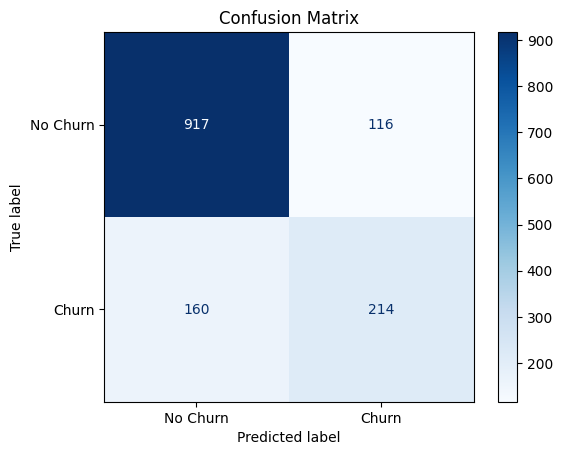

In [19]:
# =====================================================
# 11. Confusion Matrix
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [20]:
# =====================================================
# 12. Classification Report
# =====================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



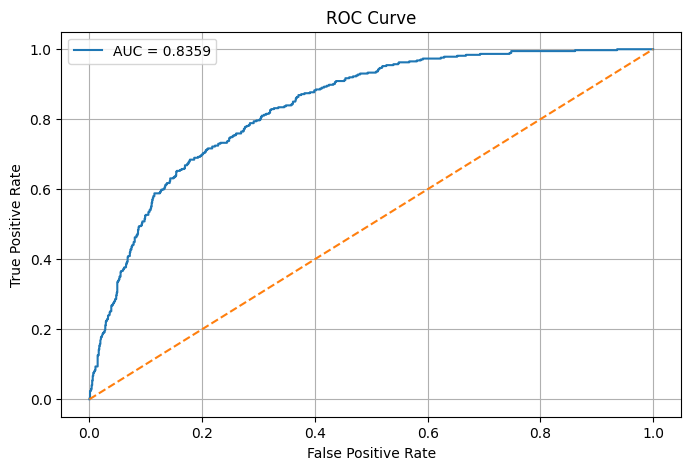


ROC AUC Score:
0.8359


In [21]:
# =====================================================
# 13. ROC Curve
# =====================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

print("\nROC AUC Score:")
print(round(auc_score, 4))

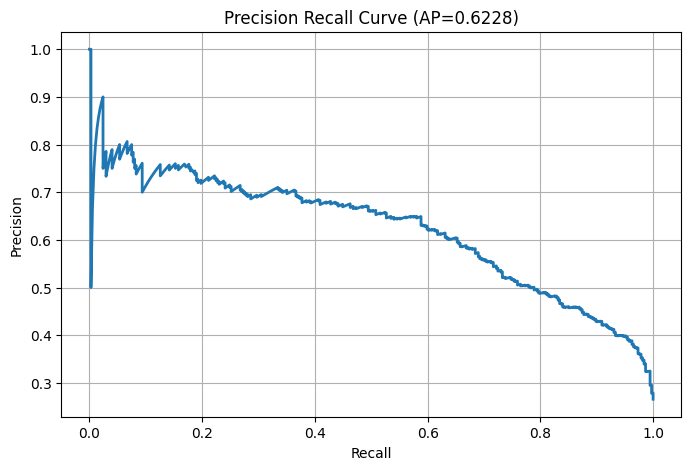


Average Precision Score:
0.6228


In [22]:
# =====================================================
# 14. Precision Recall Curve
# =====================================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    f"Precision Recall Curve (AP={ap_score:.4f})"
)

plt.grid()

plt.show()

print("\nAverage Precision Score:")
print(round(ap_score, 4))


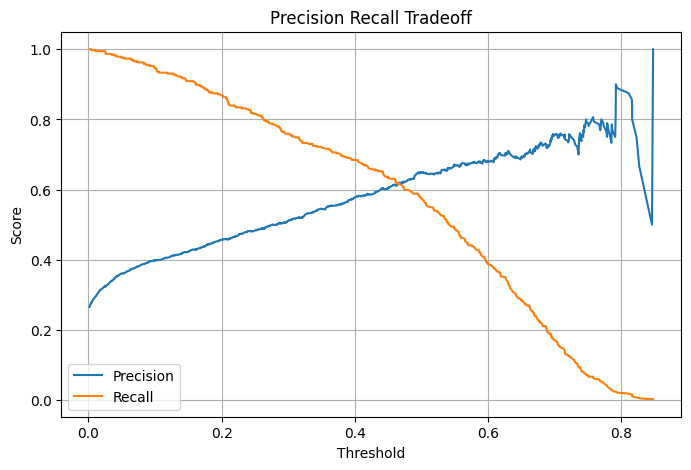

In [23]:
# =====================================================
# 15. Precision Recall Tradeoff
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Precision Recall Tradeoff"
)

plt.legend()
plt.grid()

plt.show()

In [24]:
# =====================================================
# 16. RandomizedSearchCV
# =====================================================

param_distributions = {
    "model__C": np.logspace(-4, 4, 50)
    ,
    # C = 1 / λ
    #Generates 50 values between: 10^-4 and 10^4

    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

random_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(round(
    random_search.best_score_,
    4
))

# =====================================================
# 17. Best Model
# =====================================================

best_model = random_search.best_estimator_


Best Parameters:
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(0.02811768697974228)}

Best CV Score:
0.8052


In [25]:
# =====================================================
# 18. Evaluate Tuned Model
# =====================================================

y_pred_tuned = best_model.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

print("\nBaseline Accuracy:")
print(round(baseline_accuracy, 4))

print("\nTuned Accuracy:")
print(round(tuned_accuracy, 4))


Baseline Accuracy:
0.8038

Tuned Accuracy:
0.7989


In [26]:
# =====================================================
# 19. Accuracy Comparison
# =====================================================

comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "RandomizedSearchCV Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ]
})

print("\nModel Comparison\n")
print(comparison)


Model Comparison

                                    Model  Accuracy
0            Baseline Logistic Regression  0.803838
1  RandomizedSearchCV Logistic Regression  0.798863


In [30]:
# =====================================================
# 20. Threshold Tuning Example
# =====================================================

custom_threshold = 0.5

custom_predictions = (
    y_prob >= custom_threshold
).astype(int)

custom_accuracy = accuracy_score(
    y_test,
    custom_predictions
)

print("\nAccuracy at Threshold 0.30:")
print(round(custom_accuracy, 4))

print("\nConfusion Matrix at Threshold 0.30")

print(
    confusion_matrix(
        y_test,
        custom_predictions
    )
)


Accuracy at Threshold 0.30:
0.8038

Confusion Matrix at Threshold 0.30
[[917 116]
 [160 214]]
